In [1]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import scipy
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/') # replace with your path to the dataset!
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


# Category Encoding Techniques Demonstration on Toy Dataset

In [4]:
! pip install category_encoders

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set colorblind-friendly palette
sns.set_palette("colorblind")

## Toy dataset for category encoding techniques


In [6]:
toy_data = pd.DataFrame({
    'Category': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'A', 'C', 'A', 'A', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B']
})
print("Toy Dataset for Category Encoding:")
target_data = pd.Series([5, 3, 7, 5, 3, 7, 5, 3, 7, 5, 3, 7, 5, 3, 7, 5, 3, 7, 5, 3], name='Target')
toy_data

Toy Dataset for Category Encoding:


,Category
0,A
1,B
2,C
3,A
4,B
5,C
6,A
7,A
8,C
9,A


In [7]:
toy_data.value_counts()

,count
Category,
A,9
C,6
B,5


## One-Hot Encoding

In [8]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_data = one_hot_encoder.fit_transform(toy_data[['Category']])
df_one_hot_encoded = pd.DataFrame(one_hot_encoded_data, columns=one_hot_encoder.get_feature_names_out(['Category']))
print("One-Hot Encoded values:")
df_one_hot_encoded['original'] = toy_data['Category']
df_one_hot_encoded.head(10)

One-Hot Encoded values:


,Category_A,Category_B,Category_C,original
0,1.0,0.0,0.0,A
1,0.0,1.0,0.0,B
2,0.0,0.0,1.0,C
3,1.0,0.0,0.0,A
4,0.0,1.0,0.0,B
5,0.0,0.0,1.0,C
6,1.0,0.0,0.0,A
7,1.0,0.0,0.0,A
8,0.0,0.0,1.0,C
9,1.0,0.0,0.0,A


### Plot One-Hot Encoding

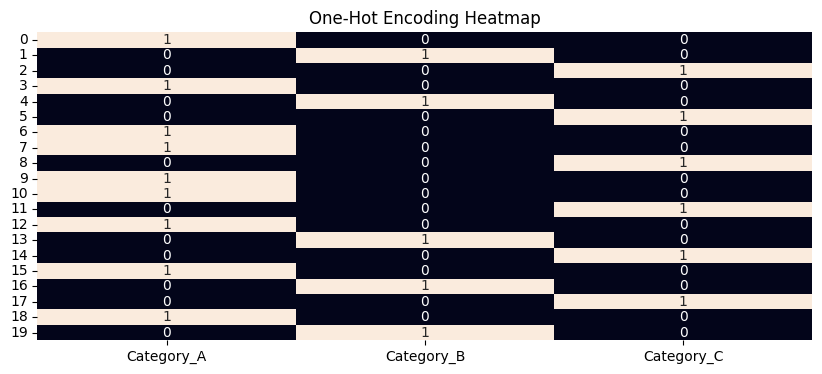

In [9]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_one_hot_encoded[['Category_A', 'Category_B',	'Category_C']], annot=True, cbar=False)
plt.title('One-Hot Encoding Heatmap')
plt.show()

## Label Encoding


In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_label_encoded = toy_data.copy()
df_label_encoded['Category'] = label_encoder.fit_transform(toy_data['Category'])
print("Label Encoded values:")
df_label_encoded

# combine with original to show mapping
df_label_encoded['Original'] = toy_data['Category']
df_label_encoded.head(5)

Label Encoded values:


,Category,Original
0,0,A
1,1,B
2,2,C
3,0,A
4,1,B


## Ordinal Encoding


In [11]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories=[['A', 'B', 'C']])
df_ordinal_encoded = toy_data.copy()
df_ordinal_encoded['Category'] = ordinal_encoder.fit_transform(toy_data[['Category']])
print("Ordinal Encoded values:")
df_ordinal_encoded.head(5)

Ordinal Encoded values:


,Category
0,0.0
1,1.0
2,2.0
3,0.0
4,1.0


## Binary Encoding


In [12]:
import category_encoders as ce

binary_encoder = ce.BinaryEncoder(cols=['Category'])
df_binary_encoded = binary_encoder.fit_transform(toy_data)
print("Binary Encoded values:")

# show original
df_binary_encoded['Original'] = toy_data['Category']
df_binary_encoded.head(5)

Binary Encoded values:


,Category_0,Category_1,Original
0,0,1,A
1,1,0,B
2,1,1,C
3,0,1,A
4,1,0,B


## Frequency Encoding

In [13]:
frequency_encoded_data = toy_data.copy()
frequency_map = toy_data['Category'].value_counts().to_dict()
frequency_encoded_data['Category'] = frequency_encoded_data['Category'].map(frequency_map)
print("Frequency Encoded values:")

frequency_encoded_data['Original'] = toy_data['Category']
frequency_encoded_data.head(10)

Frequency Encoded values:


,Category,Original
0,9,A
1,5,B
2,6,C
3,9,A
4,5,B
5,6,C
6,9,A
7,9,A
8,6,C
9,9,A


In [14]:
toy_data.value_counts()

,count
Category,
A,9
C,6
B,5


## Target Encoding

In [15]:
from category_encoders import TargetEncoder

target_encoder = TargetEncoder(cols=['Category'])
df_target_encoded = target_encoder.fit_transform(toy_data, target_data)
print("Target Encoded values:")
df_target_encoded['Original'] = toy_data['Category']
df_target_encoded.head(10)

Target Encoded values:


,Category,Original
0,4.813978,A
1,4.553392,B
2,5.315414,C
3,4.813978,A
4,4.553392,B
5,5.315414,C
6,4.813978,A
7,4.813978,A
8,5.315414,C
9,4.813978,A


## Target Encoding - Custom implementation

In [16]:
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np

def cross_validated_target_encode(df, target, column, n_splits=5):
    # Add target to the DataFrame for grouping operations
    df_with_target = df.copy()
    df_with_target['Target'] = target.values
    encoded_values = pd.Series(index=df.index, dtype=np.float64)
    global_mean = target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, val_index in kf.split(df):
        train_fold, val_fold = df_with_target.iloc[train_index], df_with_target.iloc[val_index]

        # Compute target means from the train fold
        means = train_fold.groupby(column)['Target'].mean()

        # Apply to the validation fold
        encoded_values.iloc[val_index] = val_fold[column].map(means).fillna(global_mean)

    return encoded_values

# Apply cross-validated target encoding
toy_data['Category_Encoded_CV'] = cross_validated_target_encode(toy_data, target_data, 'Category')

print("Toy Dataset with Cross-Validated Target Encoded values:")
print(toy_data)

print("\nUnique encoded values for each category:")
toy_data.groupby('Category')['Category_Encoded_CV'].mean()


Toy Dataset with Cross-Validated Target Encoded values:
   Category  Category_Encoded_CV
0         A             4.428571
1         B             3.000000
2         C             7.000000
3         A             4.500000
4         B             3.000000
5         C             7.000000
6         A             5.000000
7         A             5.000000
8         C             7.000000
9         A             4.428571
10        A             5.000000
11        C             7.000000
12        A             4.428571
13        B             3.000000
14        C             7.000000
15        A             4.428571
16        B             3.000000
17        C             7.000000
18        A             4.500000
19        B             3.000000

Unique encoded values for each category:


,Category_Encoded_CV
Category,
A,4.634921
B,3.000000
C,7.000000


In [ ]:
# Worth taking a look: https://contrib.scikit-learn.org/category_encoders/

------------

# Transformation and Encoding

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set colorblind-friendly palette
sns.set_palette("colorblind")

In [18]:
categorical_column = 'Garage Type'
numeric_column = 'Lot Frontage'

## Scaling

### Min-Max Scaling (Normalization)

In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

min_max_scaler = MinMaxScaler()
df_min_max_scaled = df.copy()
df_min_max_scaled[numeric_column] = min_max_scaler.fit_transform(df[[numeric_column]])
print("Min-Max Scaled values:")

df_min_max_scaled[numeric_column+'_original'] = df[numeric_column]
df_min_max_scaled[[numeric_column, numeric_column+'_original']].head(10)

Min-Max Scaled values:


,Lot Frontage,Lot Frontage_original
Order,,
1,0.410959,141.0
2,0.202055,80.0
3,0.205479,81.0
4,0.246575,93.0
5,0.181507,74.0
6,0.195205,78.0
7,0.068493,41.0
8,0.075342,43.0
9,0.061644,39.0


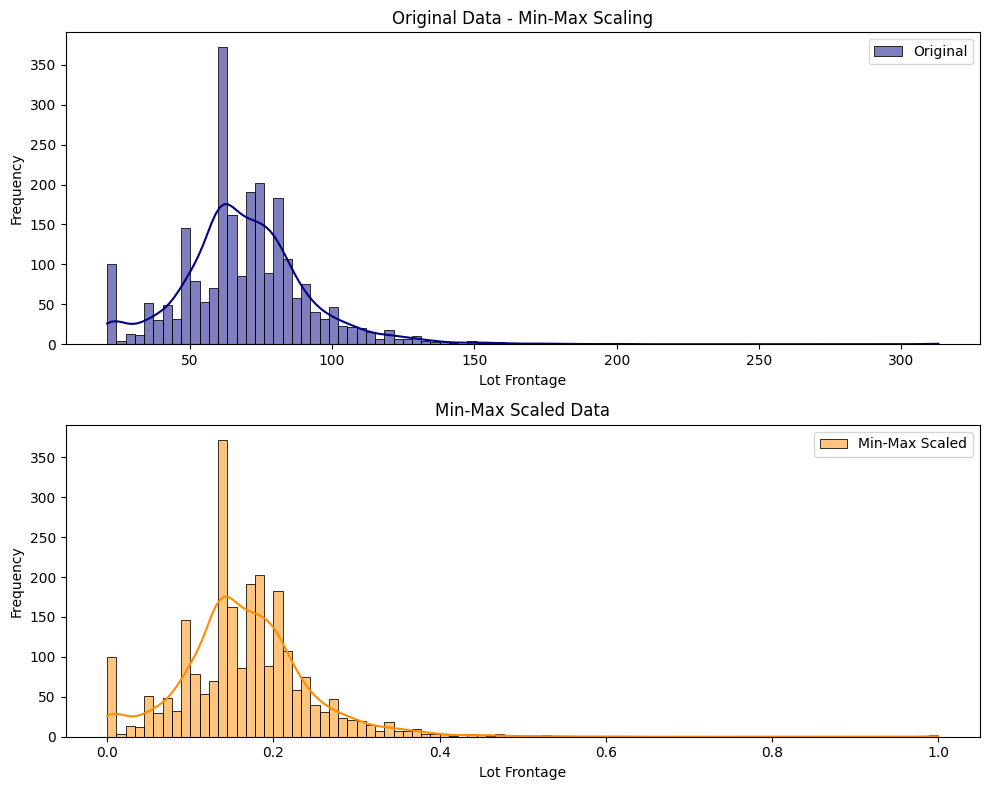

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Min-Max Scaling: Original vs Scaled on vertically stacked subplots, each with its own x-axis
fig, axes = plt.subplots(2, 1, figsize=(10, 8))  # Removed sharex=True

# Original data
sns.histplot(df[numeric_column], color='navy', label='Original', kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Original Data - Min-Max Scaling')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Min-Max Scaled data
sns.histplot(df_min_max_scaled[numeric_column], color='darkorange', label='Min-Max Scaled', kde=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Min-Max Scaled Data')
axes[1].set_xlabel(numeric_column)
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()

### Standardization

In [21]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numeric_column] = standard_scaler.fit_transform(df[[numeric_column]])
print("Standardized values:")
df_standard_scaled[numeric_column+'_original'] = df[numeric_column]
df_standard_scaled[[numeric_column, numeric_column+'_original']].head(10)

Standardized values:


,Lot Frontage,Lot Frontage_original
Order,,
1,3.072506,141.0
2,0.461265,80.0
3,0.504073,81.0
4,1.017759,93.0
5,0.204422,74.0
6,0.375651,78.0
7,-1.208216,41.0
8,-1.122602,43.0
9,-1.293831,39.0


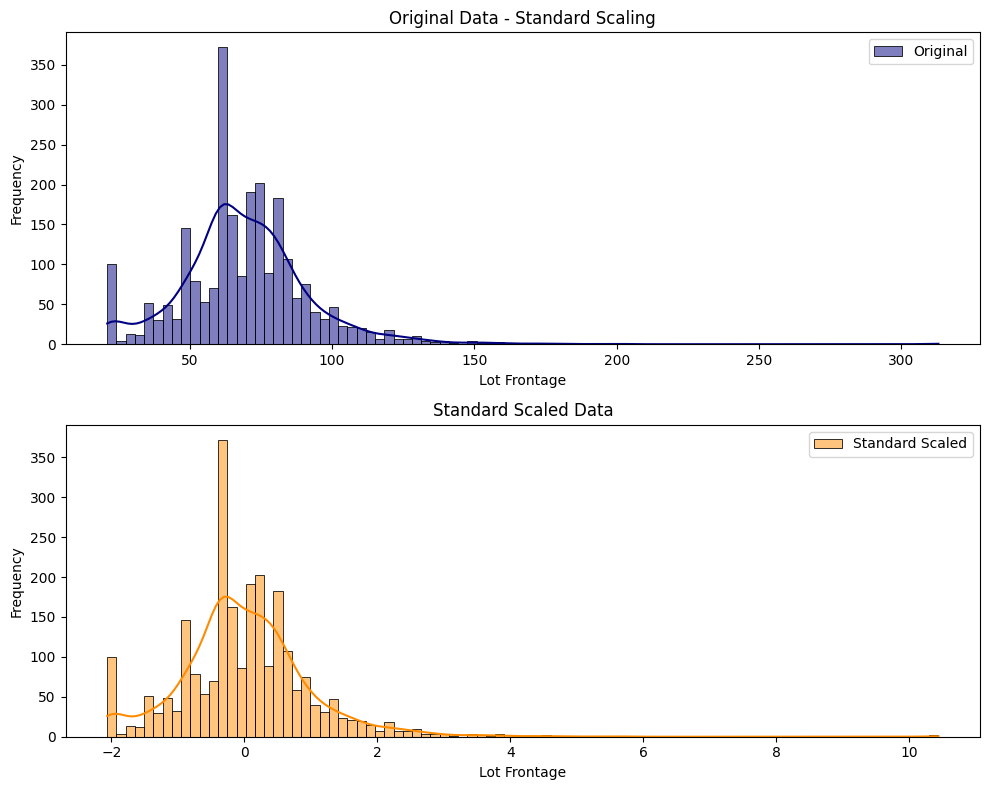

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Standard Scaling: Original vs Scaled on vertically stacked subplots, each with its own x-axis
fig, axes = plt.subplots(2, 1, figsize=(10, 8))  # Removed sharex=True

# Original data
sns.histplot(df[numeric_column], color='navy', label='Original', kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Original Data - Standard Scaling')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Standard Scaled data
sns.histplot(df_standard_scaled[numeric_column], color='darkorange', label='Standard Scaled', kde=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Standard Scaled Data')
axes[1].set_xlabel(numeric_column)
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()

### Robust Scaling

In [23]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()
df_robust_scaled = df.copy()
df_robust_scaled[numeric_column] = robust_scaler.fit_transform(df[[numeric_column]])
print("Robust Scaled values:")
df_robust_scaled[numeric_column+'_original'] = df[numeric_column]
df_robust_scaled[[numeric_column, numeric_column+'_original']].head(10)

Robust Scaled values:


,Lot Frontage,Lot Frontage_original
Order,,
1,3.318182,141.0
2,0.545455,80.0
3,0.590909,81.0
4,1.136364,93.0
5,0.272727,74.0
6,0.454545,78.0
7,-1.227273,41.0
8,-1.136364,43.0
9,-1.318182,39.0


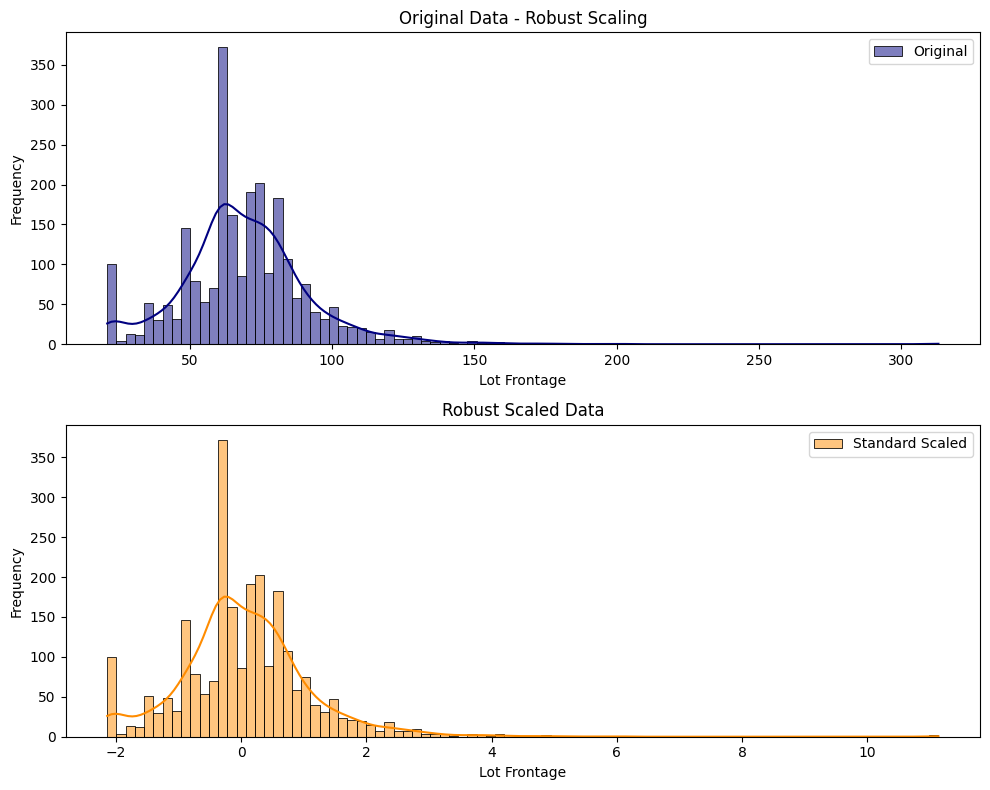

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Robust Scaling: Original vs Scaled on vertically stacked subplots, each with its own x-axis
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Original data
sns.histplot(df[numeric_column], color='navy', label='Original', kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Original Data - Robust Scaling')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Standard Scaled data
sns.histplot(df_robust_scaled[numeric_column], color='darkorange', label='Standard Scaled', kde=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Robust Scaled Data')
axes[1].set_xlabel(numeric_column)
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Adjust layout
plt.tight_layout()
plt.show()

## Transformation

### Log Transformation
... with NaN handling

In [27]:
import numpy as np
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p, validate=True)
df_log_transformed = df.copy()

# Fill NaN values with the median for numerical columns
df_log_transformed[numeric_column] = df_log_transformed[numeric_column].fillna(df_log_transformed[numeric_column].median())

# Apply log transformation
df_log_transformed[numeric_column] = log_transformer.transform(df_log_transformed[[numeric_column]])
print("Log Transformed values:")

df_log_transformed[numeric_column+'_original'] = df[numeric_column]
df_log_transformed[[numeric_column, numeric_column+'_original']].head(10)

Log Transformed values:


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


,Lot Frontage,Lot Frontage_original
Order,,
1,4.955827,141.0
2,4.394449,80.0
3,4.406719,81.0
4,4.543295,93.0
5,4.317488,74.0
6,4.369448,78.0
7,3.737670,41.0
8,3.784190,43.0
9,3.688879,39.0


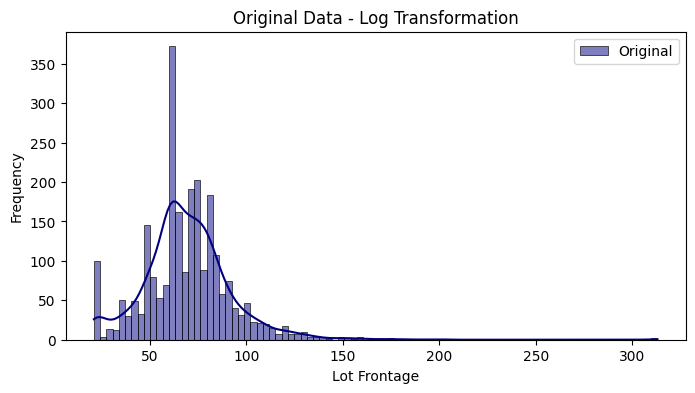

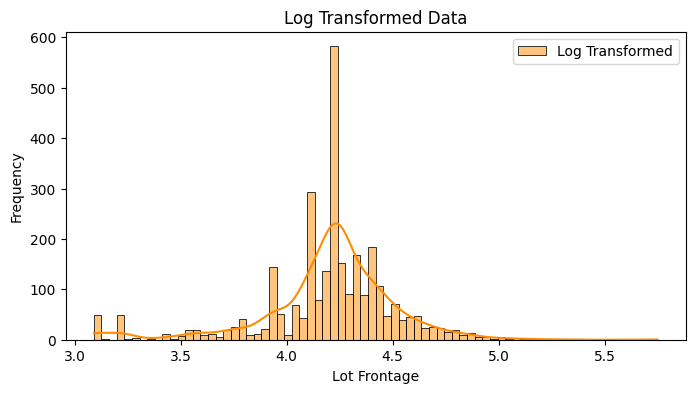

In [28]:
# Plot Log Transformation
plt.figure(figsize=(8, 4))
sns.histplot(df[numeric_column], color='navy', label='Original', kde=True, alpha=0.5)
plt.title('Original Data - Log Transformation')
plt.ylabel('Frequency')
plt.xlabel(numeric_column)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_log_transformed[numeric_column], color='darkorange', label='Log Transformed', kde=True, alpha=0.5)
plt.title('Log Transformed Data')
plt.ylabel('Frequency')
plt.xlabel(numeric_column)
plt.legend()
plt.show()


### Box-Cox Transformation

In [29]:
from scipy.stats import boxcox

df_boxcox_transformed = df.copy()
df_boxcox_transformed[numeric_column] = df_boxcox_transformed[numeric_column] + 1  # Adding 1 to avoid zero or negative values
positive_values = df_boxcox_transformed[numeric_column] > 0
transformed_data, _ = boxcox(df_boxcox_transformed.loc[positive_values, numeric_column])
df_boxcox_transformed.loc[positive_values, numeric_column] = transformed_data
print("Box-Cox Transformed values:")

df_boxcox_transformed[numeric_column+'_original'] = df[numeric_column]
df_boxcox_transformed[[numeric_column, numeric_column+'_original']].head(10)


Box-Cox Transformed values:


,Lot Frontage,Lot Frontage_original
Order,,
1,21.977243,141.0
2,16.091374,80.0
3,16.203091,81.0
4,17.494166,93.0
5,15.406135,74.0
6,15.865860,78.0
7,11.012908,41.0
8,11.320152,43.0
9,10.698286,39.0


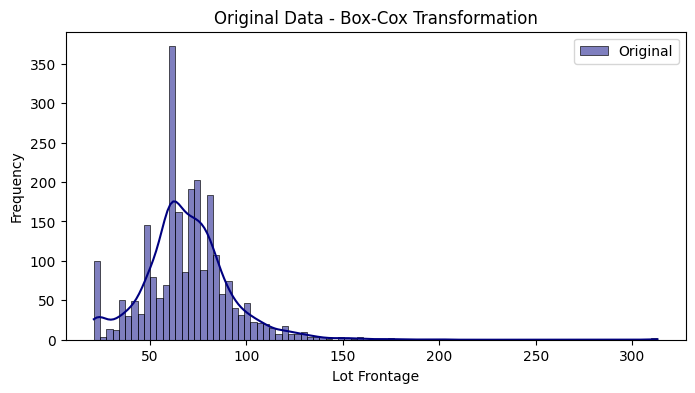

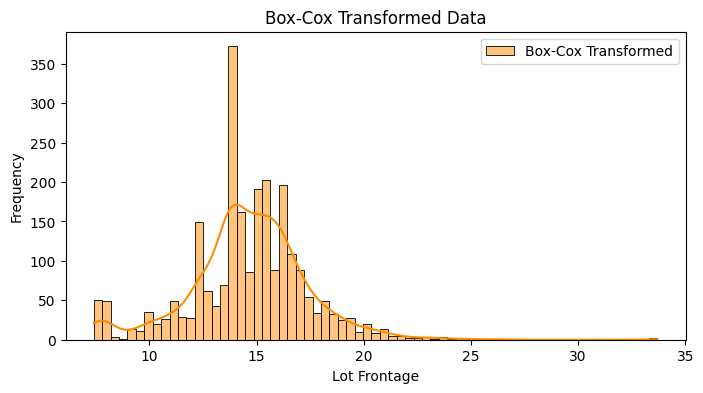

In [30]:
# Plot Box-Cox Transformation
plt.figure(figsize=(8, 4))
sns.histplot(df[numeric_column], color='navy', label='Original', kde=True, alpha=0.5)
plt.title('Original Data - Box-Cox Transformation')
plt.ylabel('Frequency')
plt.xlabel(numeric_column)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_boxcox_transformed[numeric_column], color='darkorange', label='Box-Cox Transformed', kde=True, alpha=0.5)
plt.title('Box-Cox Transformed Data')
plt.ylabel('Frequency')
plt.xlabel(numeric_column)
plt.legend()
plt.show()

### Square Root Transformation

In [31]:
df_sqrt_transformed = df.copy()
df_sqrt_transformed[numeric_column] = np.sqrt(df[[numeric_column]].fillna(df[numeric_column].median()))
print("Square Root Transformed values:")

df_sqrt_transformed[numeric_column+'_original'] = df[numeric_column]
df_sqrt_transformed[[numeric_column, numeric_column+'_original']].head(10)


Square Root Transformed values:


,Lot Frontage,Lot Frontage_original
Order,,
1,11.874342,141.0
2,8.944272,80.0
3,9.000000,81.0
4,9.643651,93.0
5,8.602325,74.0
6,8.831761,78.0
7,6.403124,41.0
8,6.557439,43.0
9,6.244998,39.0


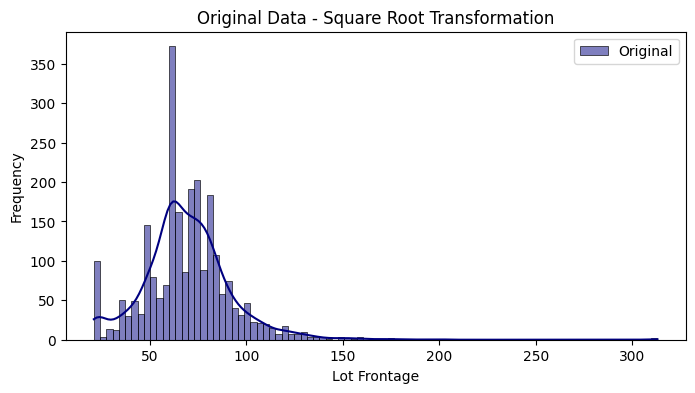

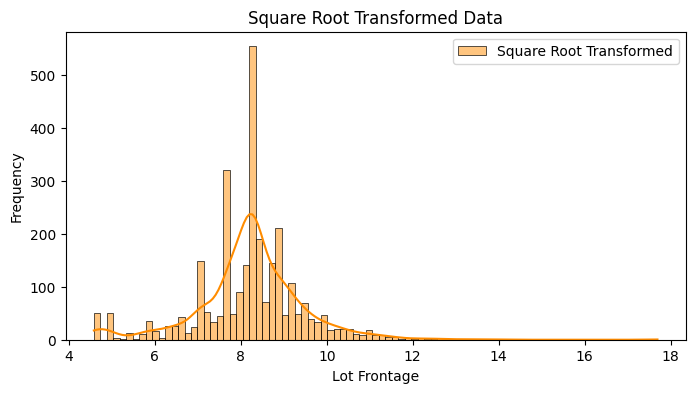

In [32]:
# Plot Square Root Transformation
plt.figure(figsize=(8, 4))
sns.histplot(df[numeric_column], color='navy', label='Original', kde=True, alpha=0.5)
plt.title('Original Data - Square Root Transformation')
plt.ylabel('Frequency')
plt.xlabel(numeric_column)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_sqrt_transformed[numeric_column], color='darkorange', label='Square Root Transformed', kde=True, alpha=0.5)
plt.title('Square Root Transformed Data')
plt.ylabel('Frequency')
plt.xlabel(numeric_column)
plt.legend()
plt.show()

## Encoding

### One Hot Encoding

In [33]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)
encoded_data = one_hot_encoder.fit_transform(df[[categorical_column]].fillna('None'))
df_one_hot_encoded = pd.DataFrame(encoded_data, columns=one_hot_encoder.get_feature_names_out([categorical_column]))
df_one_hot_encoded.index = df.index  # Align index with original dataframe
print("One-Hot Encoded values:")
df_one_hot_encoded['original'] = df[categorical_column]
df_one_hot_encoded.sample(10)

One-Hot Encoded values:


,Garage Type_2Types,Garage Type_Attchd,Garage Type_Basment,Garage Type_BuiltIn,Garage Type_CarPort,Garage Type_Detchd,Garage Type_None,original
Order,,,,,,,,
636,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Attchd
479,0.0,0.0,0.0,1.0,0.0,0.0,0.0,BuiltIn
1952,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Detchd
1712,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Attchd
40,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Attchd
1344,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Attchd
291,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN
2502,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Attchd
2238,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Detchd


### Label Encoding


In [34]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# Create a copy of the DataFrame
df_label_encoded = df.copy()
# Apply label encoding to the categorical column, handling NaN values by replacing them with 'None'
df_label_encoded[categorical_column] = label_encoder.fit_transform(df[categorical_column].fillna('None'))
df_label_encoded[categorical_column+'_original'] = df[categorical_column]
print("Label Encoded values:")
df_label_encoded[[categorical_column, categorical_column+'_original']].sample(10)


Label Encoded values:


,Garage Type,Garage Type_original
Order,,
67,1,Attchd
1685,1,Attchd
2349,1,Attchd
1378,5,Detchd
660,5,Detchd
1342,5,Detchd
1297,5,Detchd
502,1,Attchd
1831,2,Basment


# Binning

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from pathlib import Path


In [36]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/') # replace with your path to the dataset!
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [37]:
# Selecting specific column for binning examples
numeric_column = 'SalePrice'

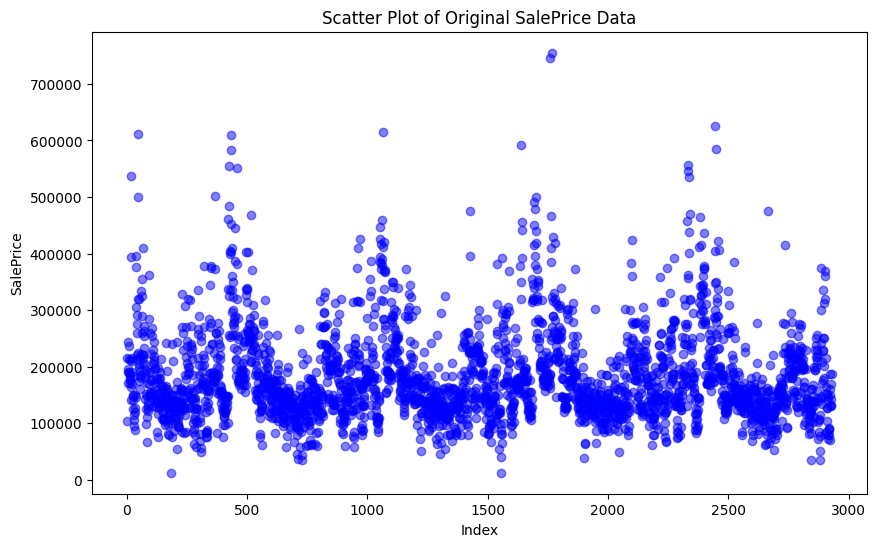

In [38]:
# Scatter plot of original SalePrice data
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df[numeric_column], color='blue', alpha=0.5)
plt.title('Scatter Plot of Original SalePrice Data')
plt.xlabel('Index')
plt.ylabel('SalePrice')
plt.show()


## Step 1: Equal-Width Binning

In [39]:
# Divides the range of values into bins of equal size
equal_width_binning = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
df_equal_width_binned = df.copy()
df_equal_width_binned['SalePrice Binned'] = equal_width_binning.fit_transform(df[[numeric_column]].fillna(df[numeric_column].median()))
print("Equal-Width Binning:")
df_equal_width_binned[['SalePrice Binned']].head()

Equal-Width Binning:


,SalePrice Binned
Order,
1,1.0
2,0.0
3,1.0
4,1.0
5,1.0


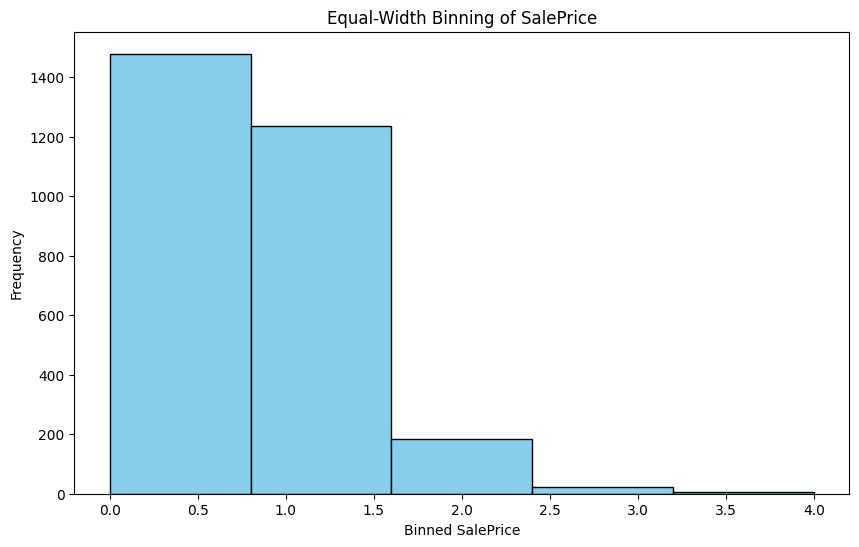

In [40]:
# Plotting Equal-Width Binning
plt.figure(figsize=(10, 6))
plt.hist(df_equal_width_binned['SalePrice Binned'], bins=5, color='skyblue', edgecolor='black')
plt.title('Equal-Width Binning of SalePrice')
plt.xlabel('Binned SalePrice')
plt.ylabel('Frequency')
plt.show()

## Step 2: Equal-Frequency Binning

In [41]:
# Each bin has approximately the same number of data points
equal_frequency_binning = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
df_equal_freq_binned = df.copy()
df_equal_freq_binned['SalePrice Binned'] = equal_frequency_binning.fit_transform(df[[numeric_column]].fillna(df[numeric_column].median()))
print("Equal-Frequency Binning:")
print(df_equal_freq_binned[['SalePrice Binned']].head())

Equal-Frequency Binning:
       SalePrice Binned
Order                  
1                   3.0
2                   0.0
3                   2.0
4                   4.0
5                   3.0


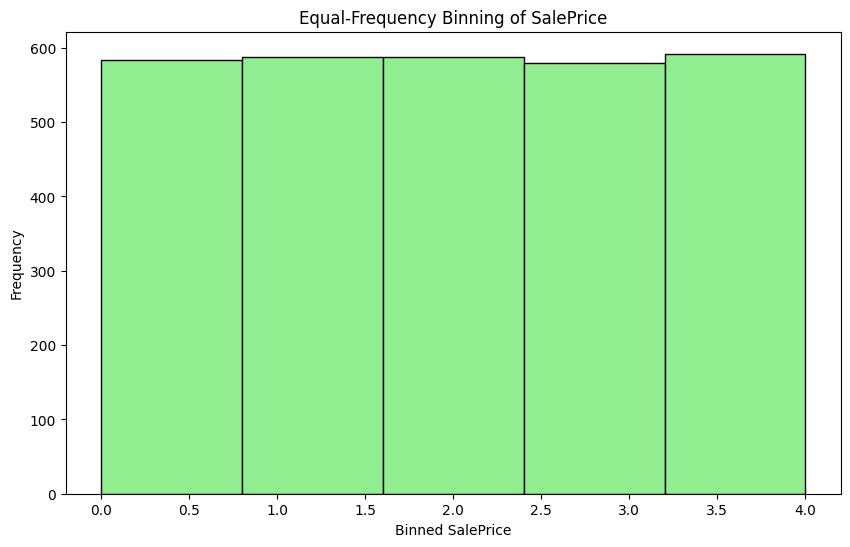

In [42]:
# Plotting Equal-Frequency Binning
plt.figure(figsize=(10, 6))
plt.hist(df_equal_freq_binned['SalePrice Binned'], bins=5, color='lightgreen', edgecolor='black')
plt.title('Equal-Frequency Binning of SalePrice')
plt.xlabel('Binned SalePrice')
plt.ylabel('Frequency')
plt.show()

## Step 3: Custom Binning

In [43]:
# User-defined bins based on domain knowledge
custom_bins = [0, 50000, 100000, 150000, 200000, np.inf]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df_custom_binned = df.copy()
df_custom_binned['SalePrice Binned'] = pd.cut(df[numeric_column].fillna(df[numeric_column].median()), bins=custom_bins, labels=labels)
print("Custom Binning:")
df_custom_binned[['SalePrice Binned']].head()

Custom Binning:


,SalePrice Binned
Order,
1,Very High
2,Medium
3,High
4,Very High
5,High


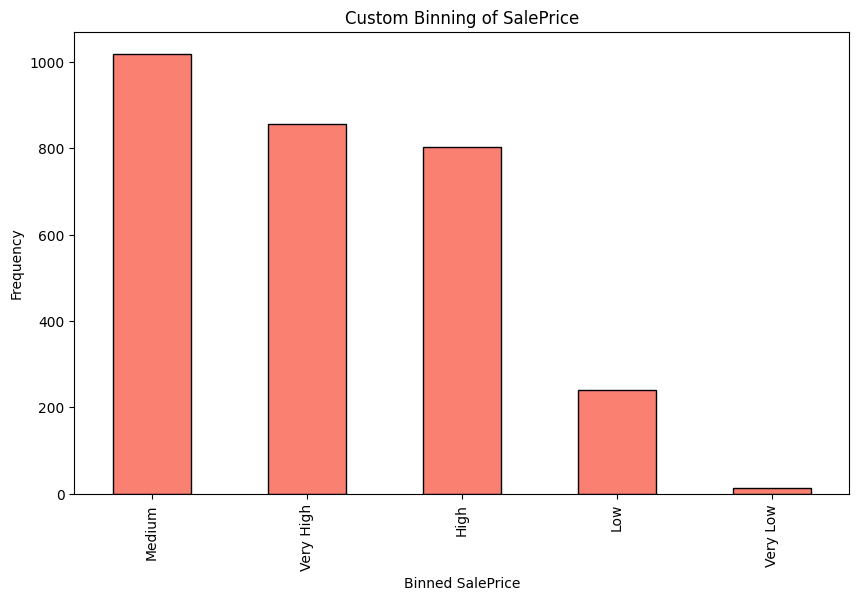

In [44]:
# Plotting Custom Binning
plt.figure(figsize=(10, 6))
df_custom_binned['SalePrice Binned'].value_counts().plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Custom Binning of SalePrice')
plt.xlabel('Binned SalePrice')
plt.ylabel('Frequency')
plt.show()

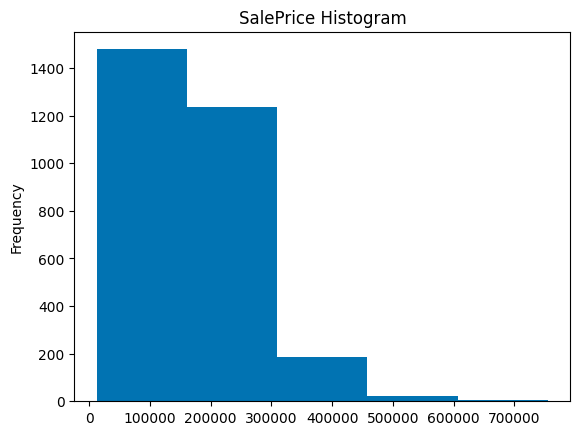

In [46]:
# plot histogram for SalePrice
df['SalePrice'].plot(kind='hist', bins=5, title='SalePrice Histogram')
plt.show()